In [ ]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

### Displaying merged data


In [ ]:
df = pd.read_csv('Merged_Flights_Weather1.csv', low_memory=False)
df.index +=2
df.head()

,FlightPlannedDateandTime,OP_UNIQUE_CARRIER,OP_CARRIER_FL_NUM,ORIGIN,DEST,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,CANCELLED,station,...,Weather Codes,ice_accretion_1hr,ice_accretion_3hr,ice_accretion_6hr,peak_wind_gust,peak_wind_drct,peak_wind_time,feel,metar,snowdepth
2,2023-12-01 6:00:00,AA,626,ABQ,PHX,600,557.0,-3.0,0.0,ABQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.59,KABQ 010552Z 28004KT 10SM SCT028 BKN040 OVC055...,NaN
3,2023-12-01 6:10:00,AA,2335,ABQ,DFW,610,605.0,-5.0,0.0,ABQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.59,KABQ 010552Z 28004KT 10SM SCT028 BKN040 OVC055...,NaN
4,2023-12-01 8:20:00,AA,1211,ABQ,DFW,820,816.0,-4.0,0.0,ABQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.00,KABQ 010752Z 00000KT 10SM BKN055 BKN070 OVC100...,NaN
5,2023-12-01 10:54:00,AA,1209,ABQ,DFW,1054,1050.0,-4.0,0.0,ABQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.22,KABQ 011052Z 20009KT 10SM FEW040 FEW055 SCT080...,NaN
6,2023-12-01 11:57:00,AA,1231,ABQ,DFW,1157,1242.0,45.0,0.0,ABQ,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.37,KABQ 011152Z 19012KT 10SM FEW035 FEW055 OVC110...,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153139 entries, 2 to 153140
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   FlightPlannedDateandTime       153139 non-null  object 
 1   OP_UNIQUE_CARRIER              153139 non-null  object 
 2   OP_CARRIER_FL_NUM              153139 non-null  int64  
 3   ORIGIN                         153139 non-null  object 
 4   DEST                           153139 non-null  object 
 5   CRS_DEP_TIME                   153139 non-null  object 
 6   DEP_TIME                       152359 non-null  float64
 7   DEP_DELAY                      152359 non-null  float64
 8   CANCELLED                      152390 non-null  float64
 9   station                        153139 non-null  object 
 10  valid                          153139 non-null  object 
 11  Temperature (F)                153106 non-null  float64
 12  Dew Point Temp(F)             

### Dropping irrelevant columns

In [ ]:
df = df.drop(columns=['Weather Codes', 'feel', 'metar'], axis=1)

### Dealing with Null values

In [ ]:
df.isna().sum()

,0
FlightPlannedDateandTime,0
OP_UNIQUE_CARRIER,0
OP_CARRIER_FL_NUM,0
ORIGIN,0
DEST,0
CRS_DEP_TIME,0
DEP_TIME,780
DEP_DELAY,780
CANCELLED,749
station,0


In [ ]:
#Calculate the ratios for each of the columns with null values
total = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum()/df['ORIGIN'].count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data

,Total,Percent
ice_accretion_3hr,153073,0.999569
ice_accretion_6hr,152994,0.999053
ice_accretion_1hr,152798,0.997773
snowdepth,152756,0.997499
Sky Level 4 Altitude (ft.),148803,0.971686
Sky Level 4 Coverage,148803,0.971686
peak_wind_drct,146063,0.953794
peak_wind_gust,146063,0.953794
peak_wind_time,146063,0.953794
Wind Gust (knots),134706,0.879632


In [ ]:
#drop temperature, dew point, Real humidity null rows
df = df.dropna(subset=['Temperature (F)'])
df= df.dropna(subset=['Dew Point Temp(F)'])
df= df.dropna(subset=['Rel. Humidity %'])
#Verify that the null rows for those 3 columns have been dropped
df.isna().sum()

,0
FlightPlannedDateandTime,0
OP_UNIQUE_CARRIER,0
OP_CARRIER_FL_NUM,0
ORIGIN,0
DEST,0
CRS_DEP_TIME,0
DEP_TIME,780
DEP_DELAY,780
CANCELLED,749
station,0


In [ ]:
# 1) normalize to strings and strip whitespace
df['Precipitation 1 hour'] = df['Precipitation 1 hour'].astype(str).str.strip()

# 2) Replace common trace notations with a tiny numeric value
df['Precipitation 1 hour'] = df['Precipitation 1 hour'].replace({'T': '0.01', 't': '0.01'})

# 4) convert to numeric (invalid -> NaN)
df['Precipitation 1 hour'] = pd.to_numeric(df['Precipitation 1 hour'], errors='coerce')

df['Precipitation 1 hour']

,Precipitation 1 hour
2,0.01
3,0.01
4,0.01
5,0.00
6,0.00
...,...
153136,0.00
153137,0.00
153138,0.01
153139,0.01


In [ ]:
#For wind speed(knots), Precipitation 1hr, Pressure Altimeter columns, visibility,calculate the avg and place it instead of the nulls
median_windSpeedKnots = df['Wind Speed (knots)'].median()
df['Wind Speed (knots)'] = df['Wind Speed (knots)'].fillna(median_windSpeedKnots)

median_precipitationPerHour = df['Precipitation 1 hour'].median()
df['Precipitation 1 hour'] = df['Precipitation 1 hour'].fillna(median_precipitationPerHour)

# pressure - usually distributed
mean_pressureAltimeter = df['Pressure Altimeter (in.)'].mean()
df['Pressure Altimeter (in.)'] = df['Pressure Altimeter (in.)'].fillna(mean_pressureAltimeter )

median_visibility = df['Visibility (miles)'].median()
df['Visibility (miles)']= df['Visibility (miles)'].fillna(median_visibility)

#verify that median imputation worked
df.isna().sum()


,0
FlightPlannedDateandTime,0
OP_UNIQUE_CARRIER,0
OP_CARRIER_FL_NUM,0
ORIGIN,0
DEST,0
CRS_DEP_TIME,0
DEP_TIME,780
DEP_DELAY,780
CANCELLED,749
station,0


In [ ]:
df['Sea Level Pressure (millibar)'] = pd.to_numeric(df['Sea Level Pressure (millibar)'])
df['Sea Level Pressure (millibar)']

,Sea Level Pressure (millibar)
2,1010.9
3,1010.9
4,1010.5
5,1009.8
6,1010.6
...,...
153136,NaN
153137,1011.4
153138,999.6
153139,998.2


In [ ]:
df['Sea Level Pressure (millibar)'] = pd.to_numeric(df['Sea Level Pressure (millibar)'])
mean_column = df['Sea Level Pressure (millibar)'].mean()
df['Sea Level Pressure (millibar)'] = df['Sea Level Pressure (millibar)'].fillna(mean_column)
df['Sea Level Pressure (millibar)']

,Sea Level Pressure (millibar)
2,1010.900000
3,1010.900000
4,1010.500000
5,1009.800000
6,1010.600000
...,...
153136,1020.671882
153137,1011.400000
153138,999.600000
153139,998.200000


In [ ]:
df['Wind Gust (knots)'] = df['Wind Gust (knots)'].fillna(-1)
df['Wind Gust (knots)']

,Wind Gust (knots)
2,-1.0
3,-1.0
4,-1.0
5,-1.0
6,-1.0
...,...
153136,21.0
153137,-1.0
153138,28.0
153139,28.0


In [ ]:
df[['Sky Level 1 Coverage', 'Sky Level 2 Coverage', 'Sky Level 3 Coverage', 'Sky Level 4 Coverage']] = df[['Sky Level 1 Coverage', 'Sky Level 2 Coverage', 'Sky Level 3 Coverage', 'Sky Level 4 Coverage']].fillna('NCD')
#NCD means No Cloud Detected
display(df[['Sky Level 1 Coverage', 'Sky Level 2 Coverage', 'Sky Level 3 Coverage', 'Sky Level 4 Coverage']])

,Sky Level 1 Coverage,Sky Level 2 Coverage,Sky Level 3 Coverage,Sky Level 4 Coverage
2,SCT,BKN,OVC,NCD
3,SCT,BKN,OVC,NCD
4,BKN,BKN,OVC,NCD
5,FEW,FEW,SCT,OVC
6,FEW,FEW,OVC,NCD
...,...,...,...,...
153136,SCT,BKN,NCD,NCD
153137,CLR,NCD,NCD,NCD
153138,CLR,NCD,NCD,NCD
153139,CLR,NCD,NCD,NCD


In [ ]:
df[['Sky Level 1 Altitude (ft.)', 'Sky Level 2 Altitude (ft.)', 'Sky Level 3 Altitude (ft.)', 'Sky Level 4 Altitude (ft.)']] = df[['Sky Level 1 Altitude (ft.)', 'Sky Level 2 Altitude (ft.)', 'Sky Level 3 Altitude (ft.)', 'Sky Level 4 Altitude (ft.)']].fillna(0)
# We're assuming that if there is a null value, then there are no clouds in that level
display(df[['Sky Level 1 Altitude (ft.)', 'Sky Level 2 Altitude (ft.)', 'Sky Level 3 Altitude (ft.)', 'Sky Level 4 Altitude (ft.)']])

,Sky Level 1 Altitude (ft.),Sky Level 2 Altitude (ft.),Sky Level 3 Altitude (ft.),Sky Level 4 Altitude (ft.)
2,2800.0,4000.0,5500.0,0.0
3,2800.0,4000.0,5500.0,0.0
4,5500.0,7000.0,10000.0,0.0
5,4000.0,5500.0,8000.0,13000.0
6,3500.0,5500.0,11000.0,0.0
...,...,...,...,...
153136,1200.0,11000.0,0.0,0.0
153137,0.0,0.0,0.0,0.0
153138,0.0,0.0,0.0,0.0
153139,0.0,0.0,0.0,0.0


In [ ]:
for col_name in ['ice_accretion_1hr', 'ice_accretion_3hr', 'ice_accretion_6hr']:
    df[col_name] = pd.to_numeric(df[col_name], errors='coerce')
df[['ice_accretion_1hr', 'ice_accretion_3hr', 'ice_accretion_6hr']] = df[['ice_accretion_1hr', 'ice_accretion_3hr', 'ice_accretion_6hr']].fillna(0)
df[['ice_accretion_1hr', 'ice_accretion_3hr', 'ice_accretion_6hr']]

,ice_accretion_1hr,ice_accretion_3hr,ice_accretion_6hr
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0
5,0.0,0.0,0.0
6,0.0,0.0,0.0
...,...,...,...
153136,0.0,0.0,0.0
153137,0.0,0.0,0.0
153138,0.0,0.0,0.0
153139,0.0,0.0,0.0


In [ ]:
df[['peak_wind_gust']] = df[['peak_wind_gust']].fillna(-1)
df[['peak_wind_gust']]

,peak_wind_gust
2,-1.0
3,-1.0
4,-1.0
5,-1.0
6,-1.0
...,...
153136,-1.0
153137,-1.0
153138,33.0
153139,28.0


In [ ]:
df[['peak_wind_drct']] = df[['peak_wind_drct']].fillna(-1)
df[['peak_wind_drct']]

,peak_wind_drct
2,-1.0
3,-1.0
4,-1.0
5,-1.0
6,-1.0
...,...
153136,-1.0
153137,-1.0
153138,180.0
153139,180.0


In [ ]:
df[['peak_wind_time']] = df[['peak_wind_time']].fillna(-1)
df[['peak_wind_time']]

,peak_wind_time
2,-1
3,-1
4,-1
5,-1
6,-1
...,...
153136,-1
153137,-1
153138,2024-12-30 17:42
153139,2024-12-30 18:29


In [ ]:
df[['DEP_TIME']] = df[['DEP_TIME']].fillna(-1)
df[['DEP_TIME']]

,DEP_TIME
2,557.0
3,605.0
4,816.0
5,1050.0
6,1242.0
...,...
153136,1832.0
153137,540.0
153138,1724.0
153139,1821.0


In [ ]:
df[['DEP_DELAY']] = df[['DEP_DELAY']].fillna(0)
df[['DEP_DELAY']]

,DEP_DELAY
2,-3.0
3,-5.0
4,-4.0
5,-4.0
6,45.0
...,...
153136,3.0
153137,37.0
153138,-8.0
153139,-8.0


In [ ]:
df[['CANCELLED']] = df[['CANCELLED']].fillna(-1)
df[['CANCELLED']]

,CANCELLED
2,0.0
3,0.0
4,0.0
5,0.0
6,0.0
...,...
153136,0.0
153137,0.0
153138,0.0
153139,0.0


In [ ]:
df['snowdepth'] = df['snowdepth'].fillna(0)
# Permanently changing df at the snowdpeth column to be zero if null
df['snowdepth']

,snowdepth
2,0.0
3,0.0
4,0.0
5,0.0
6,0.0
...,...
153136,0.0
153137,0.0
153138,0.0
153139,0.0


In [ ]:
#Handle null values in Wind Direction
# Convert to numeric
df['Wind Direction (degrees)'] = pd.to_numeric(df['Wind Direction (degrees)'], errors='coerce')

# Compute circular mean
angles_rad = np.deg2rad(df['Wind Direction (degrees)'].dropna())
circular_mean = np.rad2deg(np.arctan2(np.mean(np.sin(angles_rad)),
                                      np.mean(np.cos(angles_rad))))

# Normalize to 0–360 degrees
circular_mean = circular_mean % 360

# Impute missing values
df['Wind Direction (degrees)'] = df['Wind Direction (degrees)'].fillna(circular_mean)
df['Wind Direction (degrees)']

,Wind Direction (degrees)
2,280.0
3,280.0
4,0.0
5,200.0
6,190.0
...,...
153136,230.0
153137,230.0
153138,180.0
153139,190.0


In [ ]:
#Verify that null values have been taken care of
df.isna().sum()

,0
FlightPlannedDateandTime,0
OP_UNIQUE_CARRIER,0
OP_CARRIER_FL_NUM,0
ORIGIN,0
DEST,0
CRS_DEP_TIME,0
DEP_TIME,0
DEP_DELAY,0
CANCELLED,0
station,0


# Type Conversion
When it is reading the csv file, if pandas is not able to determine the data type of the column, it will make the type of the column an object. As such, some columns need to be converted to the 'numeric' data type.

In [ ]:
df['Visibility (miles)'] = pd.to_numeric(df['Visibility (miles)'])

In [ ]:
df['CRS_DEP_TIME'] = df['CRS_DEP_TIME'].astype(str).str.split(' ').str[0]
df['CRS_DEP_TIME'] = pd.to_numeric(df['CRS_DEP_TIME'], errors='coerce')

# Outlier Detection

We'll assume that the distribution of each column is a normal distribution. From this, we'll then detect outliers based on the statistical method.


In [ ]:
df_outliers_columns = ['CRS_DEP_TIME', 'DEP_TIME','DEP_DELAY','Temperature (F)','Dew Point Temp(F)','Rel. Humidity %', 'Wind Direction (degrees)', 'Wind Speed (knots)', 'Precipitation 1 hour', 'Pressure Altimeter (in.)', 'Sea Level Pressure (millibar)', 'Visibility (miles)', 'Sky Level 1 Altitude (ft.)', 'Sky Level 2 Altitude (ft.)', 'Sky Level 3 Altitude (ft.)','Sky Level 4 Altitude (ft.)','ice_accretion_1hr','ice_accretion_3hr','ice_accretion_6hr', 	'snowdepth']

CRS_DEP_TIME


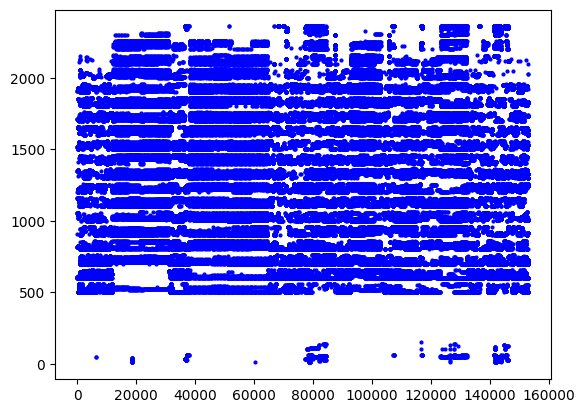

Outliers in column  CRS_DEP_TIME  are:  set()
DEP_TIME


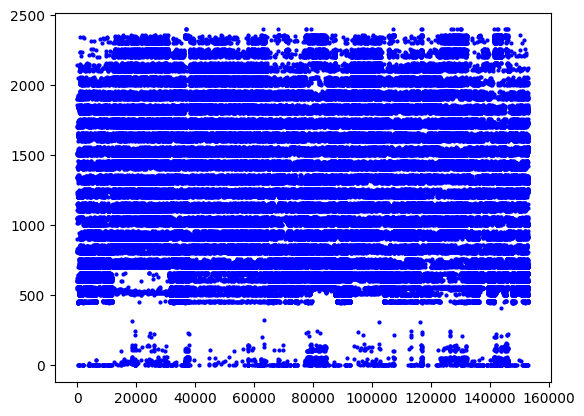

Outliers in column  DEP_TIME  are:  set()
DEP_DELAY


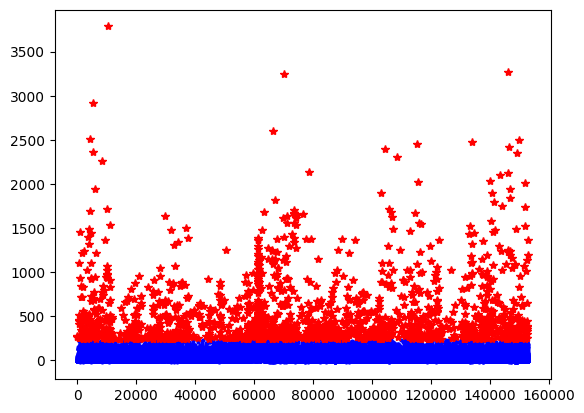

Outliers in column  DEP_DELAY  are:  {np.float64(2101.0), np.float64(2127.0), np.float64(2138.0), np.float64(2257.0), np.float64(235.0), np.float64(236.0), np.float64(237.0), np.float64(238.0), np.float64(239.0), np.float64(240.0), np.float64(241.0), np.float64(242.0), np.float64(243.0), np.float64(244.0), np.float64(245.0), np.float64(246.0), np.float64(247.0), np.float64(248.0), np.float64(249.0), np.float64(250.0), np.float64(251.0), np.float64(252.0), np.float64(253.0), np.float64(254.0), np.float64(255.0), np.float64(256.0), np.float64(257.0), np.float64(258.0), np.float64(259.0), np.float64(260.0), np.float64(261.0), np.float64(262.0), np.float64(263.0), np.float64(264.0), np.float64(265.0), np.float64(266.0), np.float64(267.0), np.float64(268.0), np.float64(269.0), np.float64(270.0), np.float64(271.0), np.float64(272.0), np.float64(273.0), np.float64(274.0), np.float64(275.0), np.float64(276.0), np.float64(277.0), np.float64(278.0), np.float64(279.0), np.float64(280.0), np.float

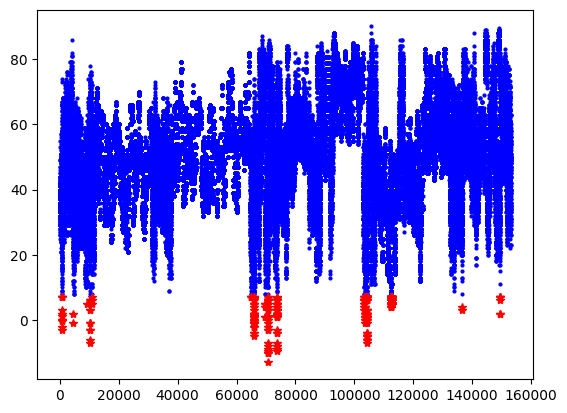

Outliers in column  Temperature (F)  are:  {np.float64(0.0), np.float64(-0.4), np.float64(2.0), np.float64(3.0), np.float64(1.4), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(1.0), np.float64(6.8), np.float64(4.0), np.float64(3.2), np.float64(-2.2), np.float64(-9.4), np.float64(-13.0), np.float64(-2.0), np.float64(-9.0), np.float64(-8.0), np.float64(-7.0), np.float64(-6.0), np.float64(-5.0), np.float64(-4.0), np.float64(-3.0), np.float64(-1.0), np.float64(-10.0)}
Dew Point Temp(F)


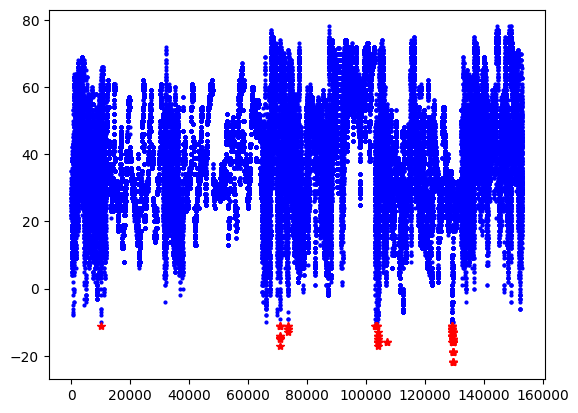

Outliers in column  Dew Point Temp(F)  are:  {np.float64(-22.0), np.float64(-19.0), np.float64(-17.0), np.float64(-16.0), np.float64(-15.0), np.float64(-14.8), np.float64(-14.0), np.float64(-12.0), np.float64(-11.0), np.float64(-13.0), np.float64(-11.2)}
Rel. Humidity %


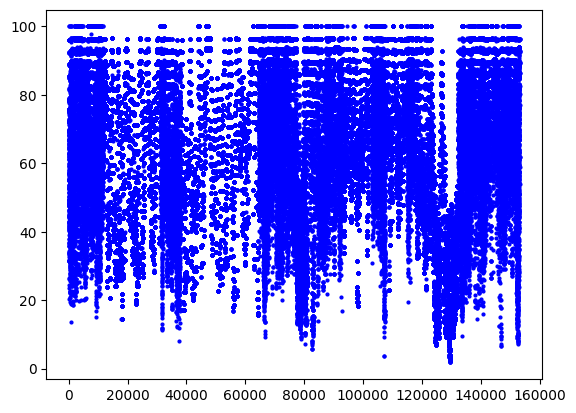

Outliers in column  Rel. Humidity %  are:  set()
Wind Direction (degrees)


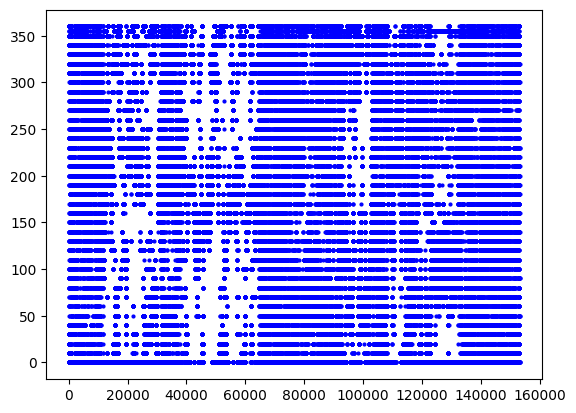

Outliers in column  Wind Direction (degrees)  are:  set()
Wind Speed (knots)


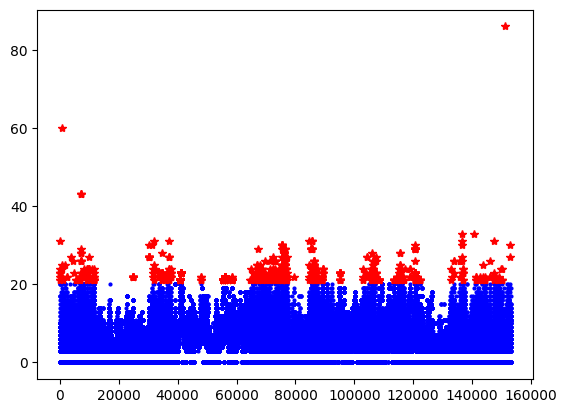

Outliers in column  Wind Speed (knots)  are:  {np.float64(33.0), np.float64(43.0), np.float64(28.0), np.float64(86.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(60.0), np.float64(29.0), np.float64(30.0), np.float64(31.0)}
Precipitation 1 hour


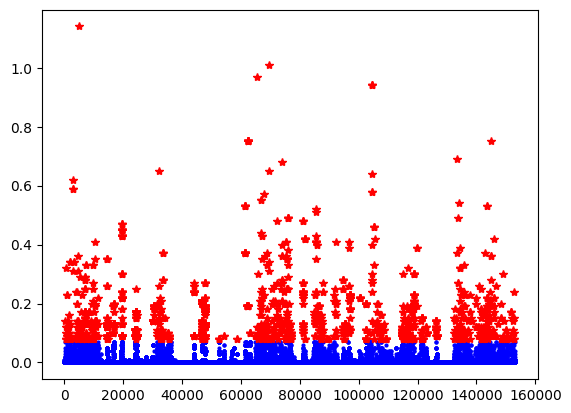

Outliers in column  Precipitation 1 hour  are:  {np.float64(0.14), np.float64(0.12), np.float64(0.32), np.float64(0.13), np.float64(0.34), np.float64(0.59), np.float64(0.36), np.float64(0.29), np.float64(0.24), np.float64(0.2), np.float64(1.14), np.float64(0.25), np.float64(0.75), np.float64(0.42), np.float64(0.26), np.float64(0.51), np.float64(0.18), np.float64(0.43), np.float64(1.01), np.float64(0.35), np.float64(0.68), np.float64(0.11), np.float64(0.27), np.float64(0.52), np.float64(0.94), np.float64(0.69), np.float64(0.19), np.float64(0.44), np.float64(0.28), np.float64(0.53), np.float64(0.45), np.float64(0.62), np.float64(0.37), np.float64(0.1), np.float64(0.09), np.float64(0.23), np.float64(0.16), np.float64(0.17), np.float64(0.15), np.float64(0.21), np.float64(0.22), np.float64(0.46), np.float64(0.38), np.float64(0.54), np.float64(0.3), np.float64(0.47), np.float64(0.97), np.float64(0.55), np.float64(0.39), np.float64(0.64), np.float64(0.31), np.float64(0.08), np.float64(0.48), 

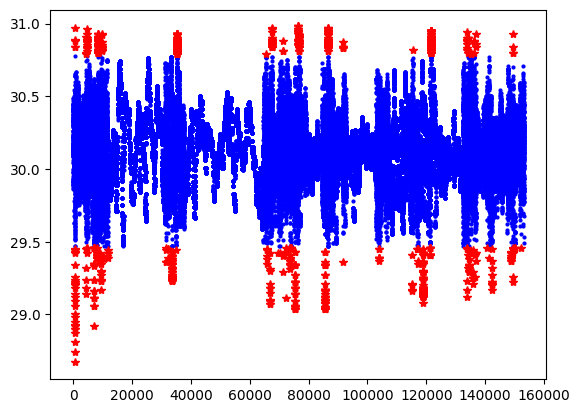

Outliers in column  Pressure Altimeter (in.)  are:  {np.float64(29.27), np.float64(30.82), np.float64(30.95), np.float64(29.46), np.float64(29.4), np.float64(28.93), np.float64(28.95), np.float64(28.9), np.float64(28.87), np.float64(28.81), np.float64(29.06), np.float64(29.0), np.float64(29.12), np.float64(29.43), np.float64(29.09), np.float64(30.84), np.float64(29.22), np.float64(29.42), np.float64(29.45), np.float64(29.18), np.float64(28.92), np.float64(29.24), np.float64(28.98), np.float64(28.67), np.float64(29.34), np.float64(29.44), np.float64(29.14), np.float64(30.89), np.float64(29.2), np.float64(29.21), np.float64(30.97), np.float64(30.88), np.float64(30.96), np.float64(30.9), np.float64(28.74), np.float64(29.35), np.float64(29.16), np.float64(29.29), np.float64(29.1), np.float64(29.04), np.float64(29.23), np.float64(29.39), np.float64(29.41), np.float64(29.11), np.float64(30.91), np.float64(29.36), np.float64(29.17), np.float64(29.3), np.float64(30.79), np.float64(30.85), np.f

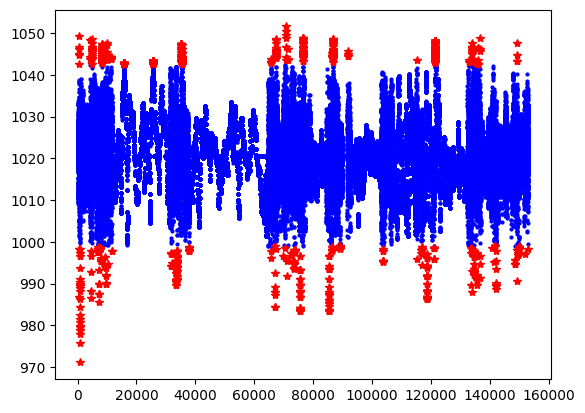

Outliers in column  Sea Level Pressure (millibar)  are:  {np.float64(1042.7), np.float64(1043.2), np.float64(1043.3), np.float64(1043.6), np.float64(1044.6), np.float64(1044.9), np.float64(1045.6), np.float64(1045.4), np.float64(1045.3), np.float64(1045.9), np.float64(1045.7), np.float64(1046.7), np.float64(1046.0), np.float64(1046.3), np.float64(1049.3), np.float64(1048.4), np.float64(1050.4), np.float64(1051.6), np.float64(1042.8), np.float64(1042.6), np.float64(1042.9), np.float64(1042.5), np.float64(1043.7), np.float64(1043.8), np.float64(1043.9), np.float64(1043.5), np.float64(1043.4), np.float64(1044.8), np.float64(1044.3), np.float64(1044.1), np.float64(1044.5), np.float64(1044.7), np.float64(1045.0), np.float64(1045.8), np.float64(1045.5), np.float64(1045.1), np.float64(1044.2), np.float64(1046.6), np.float64(1046.1), np.float64(1046.4), np.float64(1046.9), np.float64(1046.2), np.float64(1047.6), np.float64(1047.3), np.float64(1047.2), np.float64(1047.1), np.float64(1047.4), np

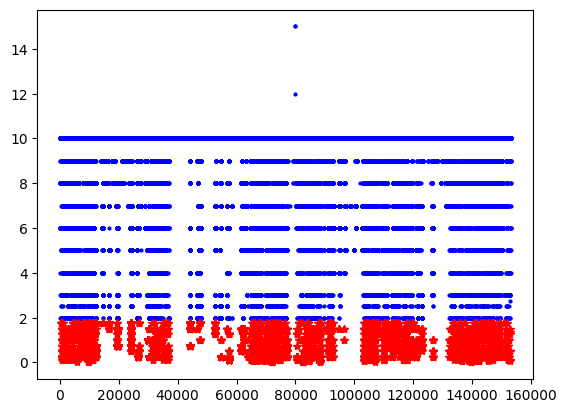

Outliers in column  Visibility (miles)  are:  {np.float64(0.25), np.float64(1.75), np.float64(1.0), np.float64(1.5), np.float64(0.5), np.float64(0.75), np.float64(1.25), np.float64(0.12), np.float64(0.0), np.float64(0.06), np.float64(1.38)}
Sky Level 1 Altitude (ft.)


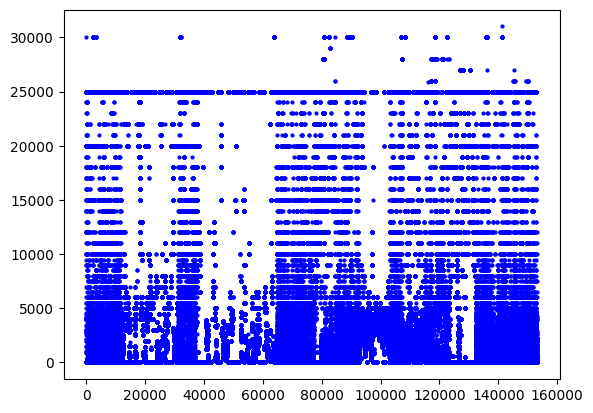

Outliers in column  Sky Level 1 Altitude (ft.)  are:  set()
Sky Level 2 Altitude (ft.)


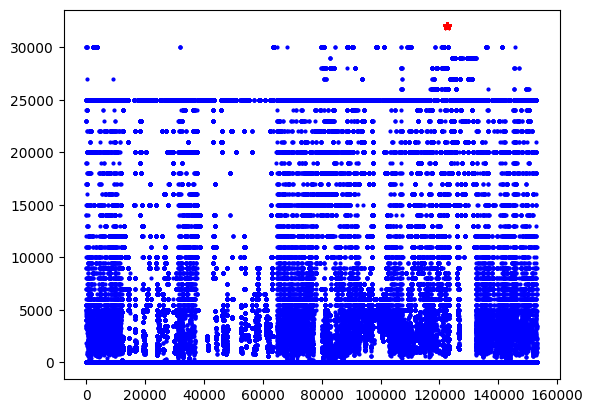

Outliers in column  Sky Level 2 Altitude (ft.)  are:  {np.float64(32000.0)}
Sky Level 3 Altitude (ft.)


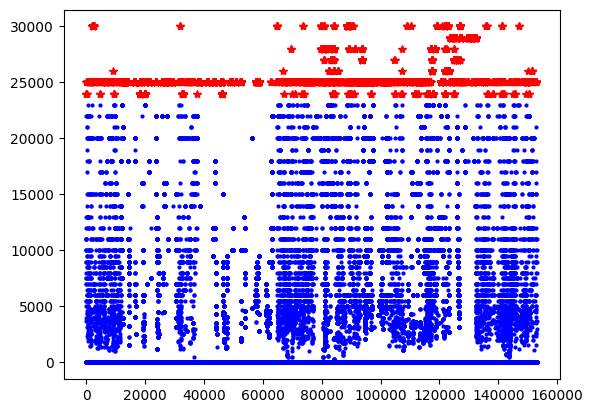

Outliers in column  Sky Level 3 Altitude (ft.)  are:  {np.float64(28000.0), np.float64(24000.0), np.float64(25000.0), np.float64(29000.0), np.float64(30000.0), np.float64(26000.0), np.float64(27000.0)}
Sky Level 4 Altitude (ft.)


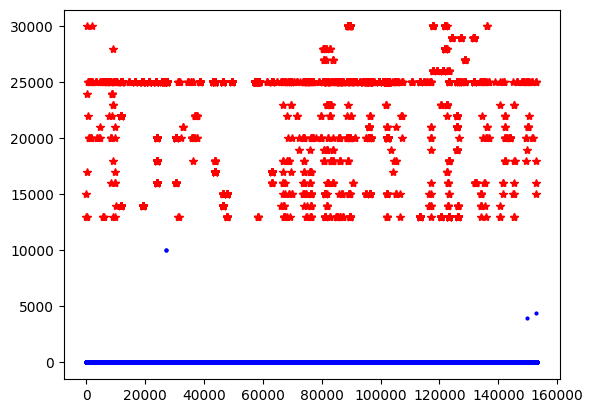

Outliers in column  Sky Level 4 Altitude (ft.)  are:  {np.float64(24000.0), np.float64(20000.0), np.float64(16000.0), np.float64(28000.0), np.float64(27000.0), np.float64(23000.0), np.float64(13000.0), np.float64(17000.0), np.float64(25000.0), np.float64(21000.0), np.float64(19000.0), np.float64(29000.0), np.float64(30000.0), np.float64(22000.0), np.float64(18000.0), np.float64(14000.0), np.float64(26000.0), np.float64(15000.0)}
ice_accretion_1hr


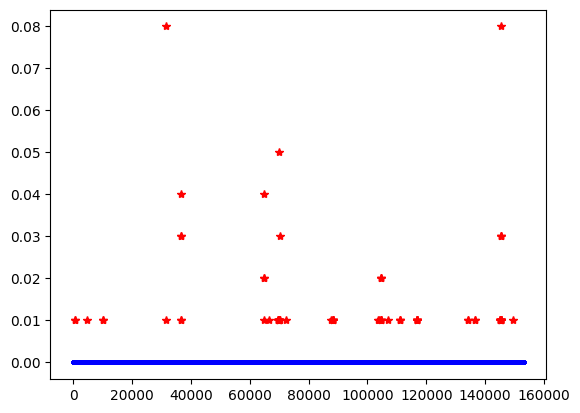

Outliers in column  ice_accretion_1hr  are:  {np.float64(0.08), np.float64(0.03), np.float64(0.05), np.float64(0.01), np.float64(0.04), np.float64(0.02)}
ice_accretion_3hr


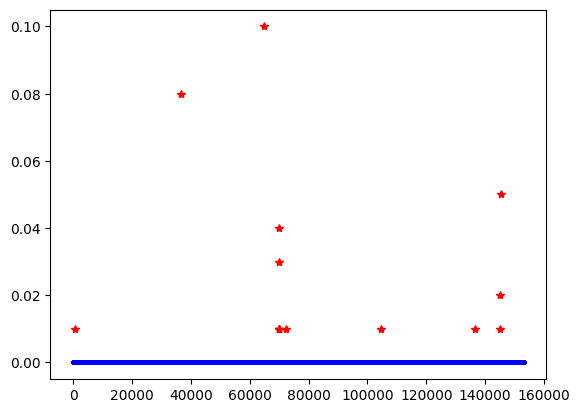

Outliers in column  ice_accretion_3hr  are:  {np.float64(0.08), np.float64(0.1), np.float64(0.03), np.float64(0.05), np.float64(0.01), np.float64(0.04), np.float64(0.02)}
ice_accretion_6hr


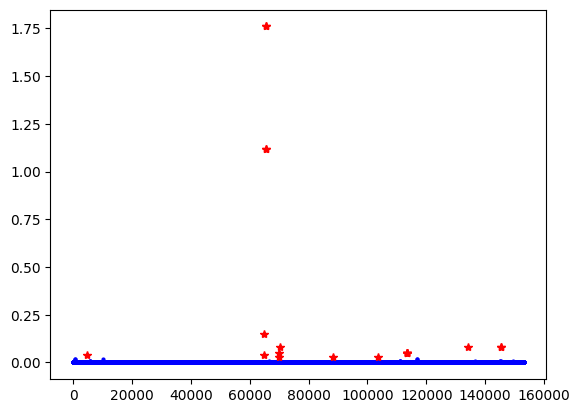

Outliers in column  ice_accretion_6hr  are:  {np.float64(0.03), np.float64(1.76), np.float64(1.12), np.float64(0.15), np.float64(0.05), np.float64(0.08), np.float64(0.04)}
snowdepth


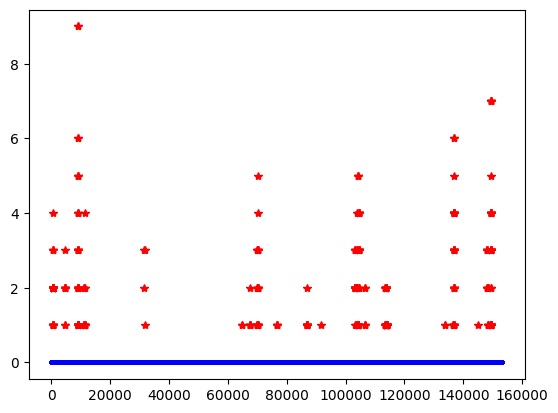

Outliers in column  snowdepth  are:  {np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(9.0)}


In [ ]:
def detect_outliers (col):
    outliers = set()
    m = col.mean()
    s = col.std()
    for p in col.unique():
        if (abs(p-m) > 3 * s): # Possible to change 3 to other values
            outliers.add(p)
    outliers_indexes = col.isin(outliers)
    plt.plot(col, color='blue', marker='o', ms = 2, linewidth = 0)
    plt.plot(col, color='red', markevery = outliers_indexes, marker='*', ms = 6, linewidth = 0)
    plt.show()
    return outliers

def get_outliers_from_column(df, col_name):
    col = df[col_name]
    outliers = detect_outliers(col)
    return outliers

for col in df_outliers_columns:
    print(col)
    outliers = get_outliers_from_column(df, col)
    print("Outliers in column ", col, " are: ", outliers)

### After removing outliers
*Only certain columns have outliers that need to be removed.*

#### DEP_DELAY
Removing data that has more than 2500 minutes

In [ ]:
df = df.drop(df[df['DEP_DELAY'] > 2500].index)

#### WindSpeed (knot)
Remove data that are above 40 as there are not enough cases to support these circumstances.

In [ ]:
df = df.drop(df[df['Wind Speed (knots)'] > 40].index)

#### Precipitation

In [ ]:
df = df.drop(df[df['Precipitation 1 hour'] > 1.0].index)

#### Sky Level 2 Altitude

In [ ]:
df = df.drop(df[df['Sky Level 2 Altitude (ft.)'] == 32000].index)

#### Plotting new graphs

CRS_DEP_TIME


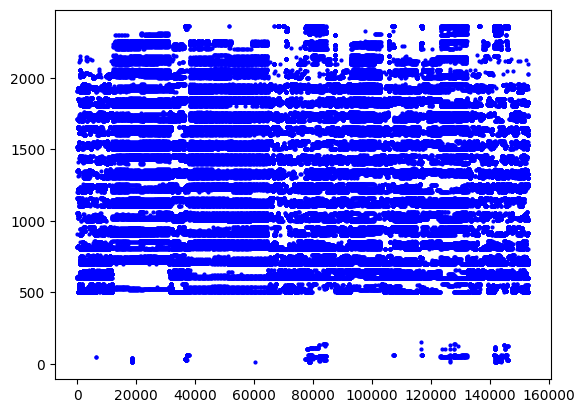

Outliers in column  CRS_DEP_TIME  are:  set()
DEP_TIME


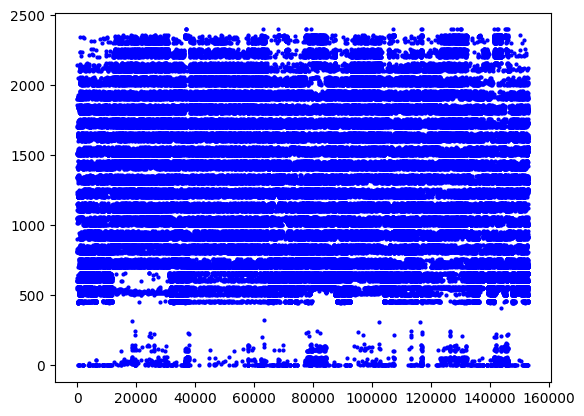

Outliers in column  DEP_TIME  are:  set()
DEP_DELAY


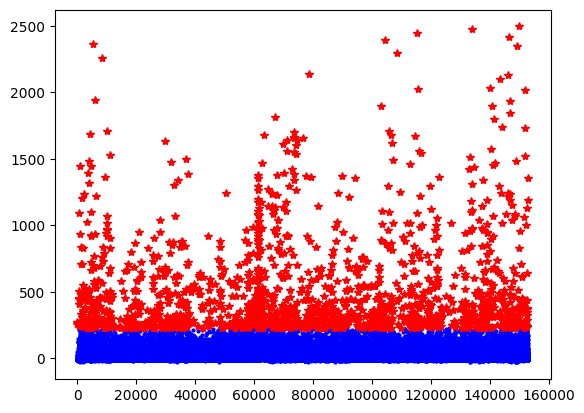

Outliers in column  DEP_DELAY  are:  {np.float64(2101.0), np.float64(2127.0), np.float64(2138.0), np.float64(2257.0), np.float64(227.0), np.float64(228.0), np.float64(229.0), np.float64(230.0), np.float64(231.0), np.float64(232.0), np.float64(233.0), np.float64(234.0), np.float64(235.0), np.float64(236.0), np.float64(237.0), np.float64(238.0), np.float64(239.0), np.float64(240.0), np.float64(241.0), np.float64(242.0), np.float64(243.0), np.float64(244.0), np.float64(245.0), np.float64(246.0), np.float64(247.0), np.float64(248.0), np.float64(249.0), np.float64(250.0), np.float64(251.0), np.float64(252.0), np.float64(253.0), np.float64(254.0), np.float64(255.0), np.float64(256.0), np.float64(257.0), np.float64(258.0), np.float64(259.0), np.float64(260.0), np.float64(261.0), np.float64(262.0), np.float64(263.0), np.float64(264.0), np.float64(265.0), np.float64(266.0), np.float64(267.0), np.float64(268.0), np.float64(269.0), np.float64(270.0), np.float64(271.0), np.float64(272.0), np.float

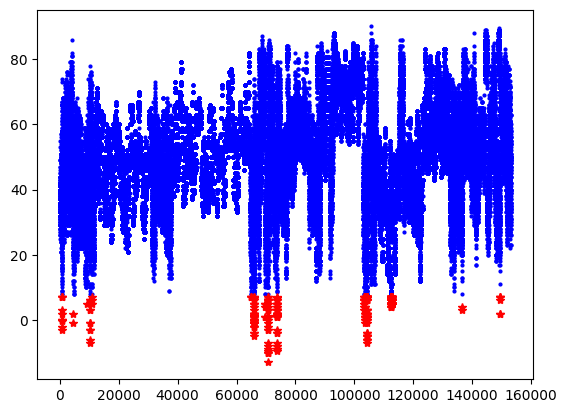

Outliers in column  Temperature (F)  are:  {np.float64(0.0), np.float64(-0.4), np.float64(2.0), np.float64(3.0), np.float64(1.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(6.8), np.float64(1.4), np.float64(4.0), np.float64(3.2), np.float64(-2.2), np.float64(-9.4), np.float64(-13.0), np.float64(-2.0), np.float64(-9.0), np.float64(-8.0), np.float64(-7.0), np.float64(-6.0), np.float64(-5.0), np.float64(-4.0), np.float64(-3.0), np.float64(-1.0), np.float64(-10.0)}
Dew Point Temp(F)


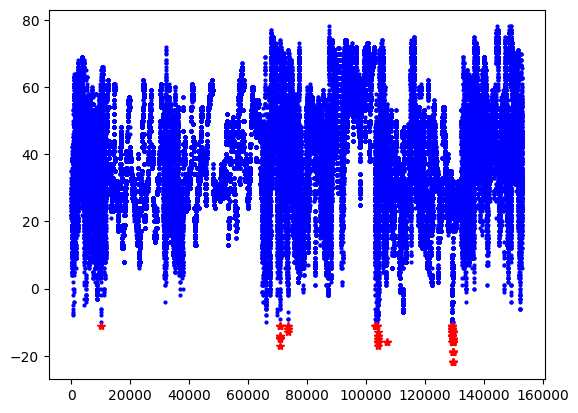

Outliers in column  Dew Point Temp(F)  are:  {np.float64(-22.0), np.float64(-19.0), np.float64(-17.0), np.float64(-16.0), np.float64(-15.0), np.float64(-14.8), np.float64(-14.0), np.float64(-12.0), np.float64(-11.0), np.float64(-13.0), np.float64(-11.2)}
Rel. Humidity %


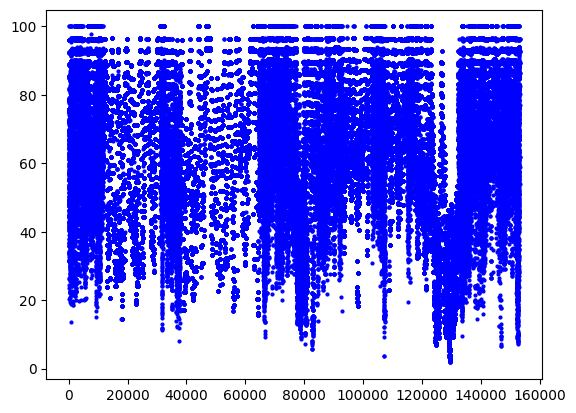

Outliers in column  Rel. Humidity %  are:  set()
Wind Direction (degrees)


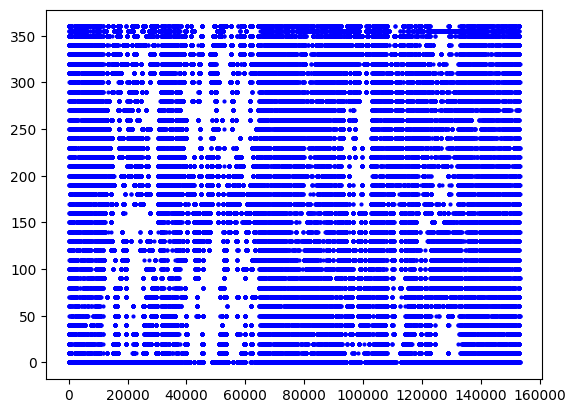

Outliers in column  Wind Direction (degrees)  are:  set()
Wind Speed (knots)


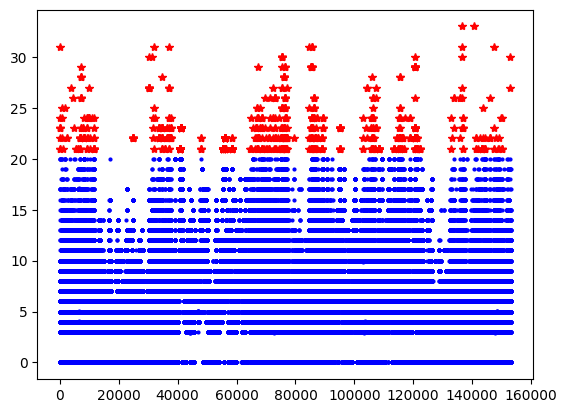

Outliers in column  Wind Speed (knots)  are:  {np.float64(33.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(28.0), np.float64(29.0), np.float64(30.0), np.float64(31.0)}
Precipitation 1 hour


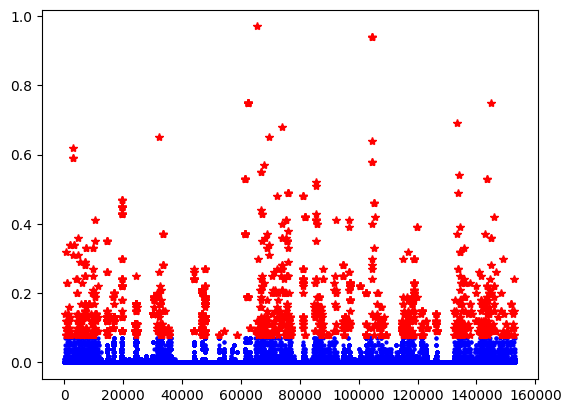

Outliers in column  Precipitation 1 hour  are:  {np.float64(0.14), np.float64(0.12), np.float64(0.32), np.float64(0.13), np.float64(0.34), np.float64(0.59), np.float64(0.36), np.float64(0.29), np.float64(0.24), np.float64(0.2), np.float64(0.25), np.float64(0.75), np.float64(0.42), np.float64(0.26), np.float64(0.51), np.float64(0.18), np.float64(0.43), np.float64(0.35), np.float64(0.68), np.float64(0.11), np.float64(0.27), np.float64(0.52), np.float64(0.94), np.float64(0.69), np.float64(0.19), np.float64(0.44), np.float64(0.28), np.float64(0.53), np.float64(0.45), np.float64(0.62), np.float64(0.37), np.float64(0.1), np.float64(0.09), np.float64(0.23), np.float64(0.16), np.float64(0.17), np.float64(0.15), np.float64(0.21), np.float64(0.22), np.float64(0.46), np.float64(0.38), np.float64(0.54), np.float64(0.3), np.float64(0.47), np.float64(0.97), np.float64(0.55), np.float64(0.39), np.float64(0.64), np.float64(0.31), np.float64(0.08), np.float64(0.48), np.float64(0.65), np.float64(0.57), 

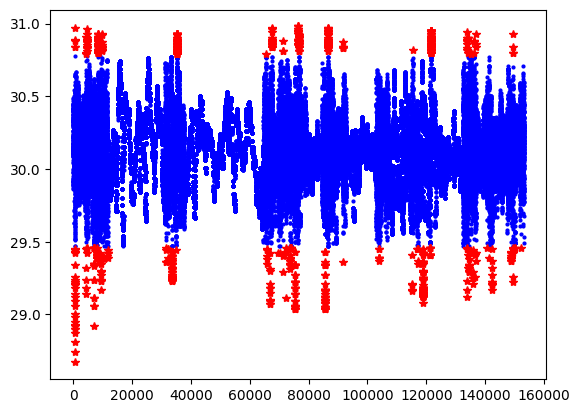

Outliers in column  Pressure Altimeter (in.)  are:  {np.float64(29.27), np.float64(30.82), np.float64(30.95), np.float64(29.46), np.float64(29.4), np.float64(28.93), np.float64(28.95), np.float64(28.9), np.float64(28.87), np.float64(28.81), np.float64(29.06), np.float64(29.0), np.float64(29.12), np.float64(29.43), np.float64(29.09), np.float64(30.84), np.float64(29.22), np.float64(29.42), np.float64(29.45), np.float64(29.18), np.float64(28.92), np.float64(29.24), np.float64(28.98), np.float64(28.67), np.float64(29.34), np.float64(29.44), np.float64(29.14), np.float64(30.89), np.float64(29.2), np.float64(29.21), np.float64(30.97), np.float64(30.88), np.float64(30.96), np.float64(30.9), np.float64(28.74), np.float64(29.35), np.float64(29.41), np.float64(29.29), np.float64(29.1), np.float64(29.04), np.float64(29.23), np.float64(29.39), np.float64(29.16), np.float64(29.11), np.float64(30.91), np.float64(29.36), np.float64(29.17), np.float64(29.3), np.float64(30.79), np.float64(30.85), np.f

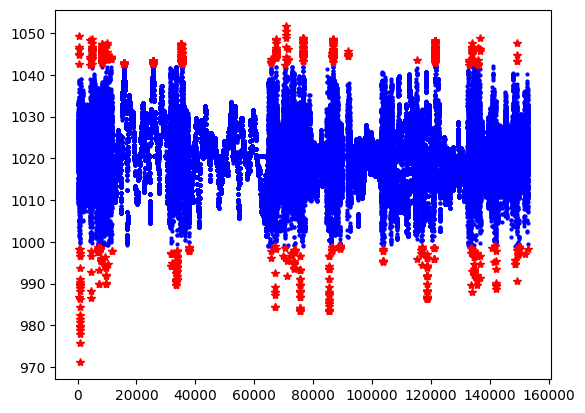

Outliers in column  Sea Level Pressure (millibar)  are:  {np.float64(1042.7), np.float64(1043.2), np.float64(1043.3), np.float64(1043.6), np.float64(1044.5), np.float64(1044.6), np.float64(1044.9), np.float64(1045.6), np.float64(1045.4), np.float64(1045.3), np.float64(1045.9), np.float64(1045.7), np.float64(1046.7), np.float64(1046.0), np.float64(1049.3), np.float64(1048.4), np.float64(1050.4), np.float64(1051.6), np.float64(1042.4), np.float64(1042.8), np.float64(1042.6), np.float64(1042.9), np.float64(1042.5), np.float64(1043.7), np.float64(1043.8), np.float64(1043.9), np.float64(1043.5), np.float64(1043.4), np.float64(1044.8), np.float64(1044.3), np.float64(1044.1), np.float64(1044.7), np.float64(1044.2), np.float64(1045.0), np.float64(1045.8), np.float64(1045.5), np.float64(1045.1), np.float64(1044.0), np.float64(1046.3), np.float64(1046.6), np.float64(1046.1), np.float64(1046.4), np.float64(1046.9), np.float64(1047.6), np.float64(1047.3), np.float64(1047.2), np.float64(1047.1), np

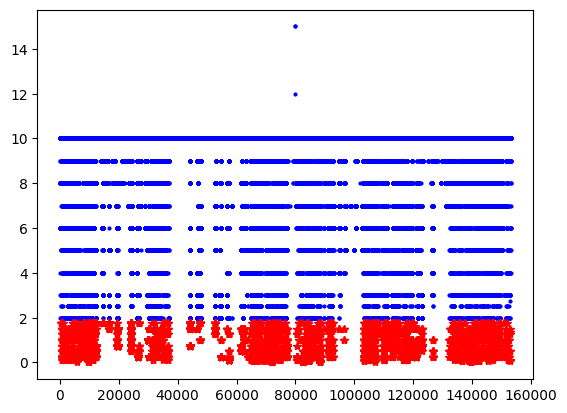

Outliers in column  Visibility (miles)  are:  {np.float64(0.25), np.float64(1.75), np.float64(1.0), np.float64(1.5), np.float64(0.5), np.float64(0.75), np.float64(1.25), np.float64(0.12), np.float64(0.0), np.float64(0.06), np.float64(1.38)}
Sky Level 1 Altitude (ft.)


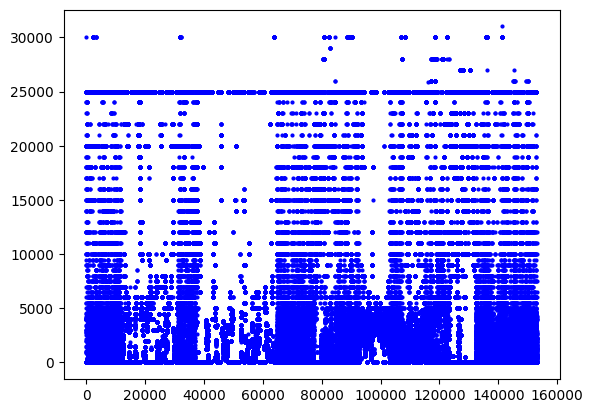

Outliers in column  Sky Level 1 Altitude (ft.)  are:  set()
Sky Level 2 Altitude (ft.)


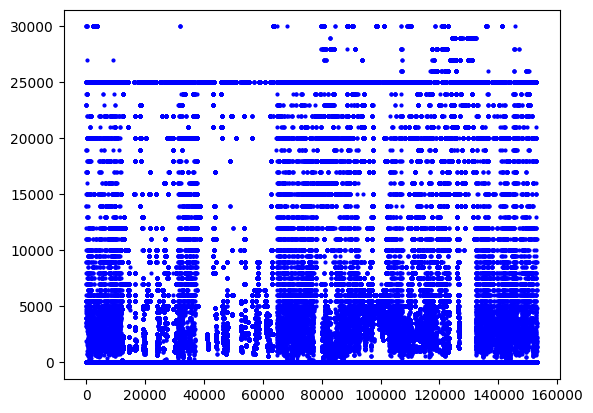

Outliers in column  Sky Level 2 Altitude (ft.)  are:  set()
Sky Level 3 Altitude (ft.)


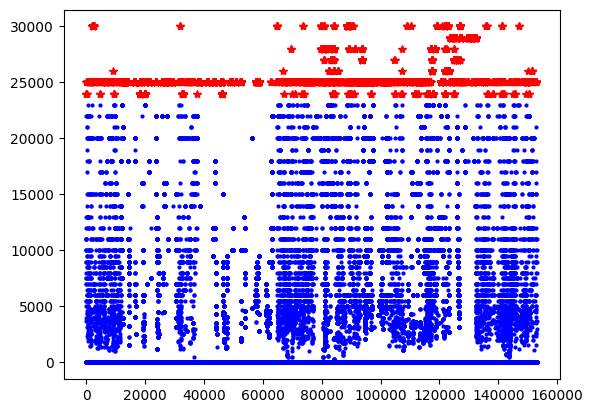

Outliers in column  Sky Level 3 Altitude (ft.)  are:  {np.float64(28000.0), np.float64(24000.0), np.float64(25000.0), np.float64(29000.0), np.float64(30000.0), np.float64(26000.0), np.float64(27000.0)}
Sky Level 4 Altitude (ft.)


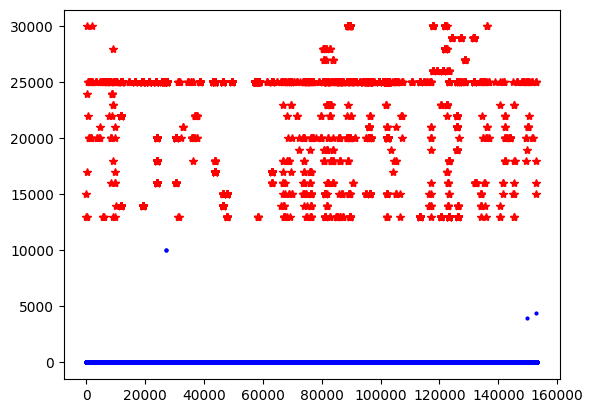

Outliers in column  Sky Level 4 Altitude (ft.)  are:  {np.float64(24000.0), np.float64(20000.0), np.float64(16000.0), np.float64(28000.0), np.float64(27000.0), np.float64(23000.0), np.float64(13000.0), np.float64(17000.0), np.float64(25000.0), np.float64(21000.0), np.float64(19000.0), np.float64(29000.0), np.float64(30000.0), np.float64(22000.0), np.float64(18000.0), np.float64(14000.0), np.float64(26000.0), np.float64(15000.0)}
ice_accretion_1hr


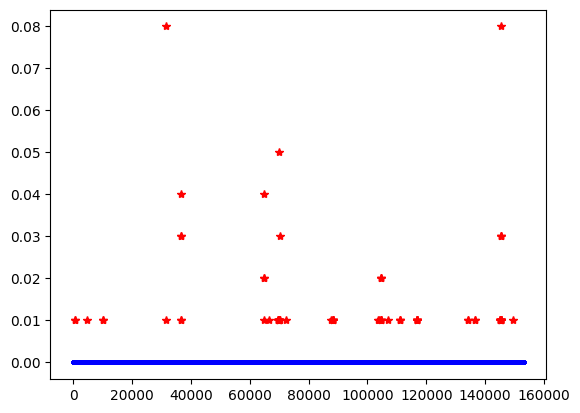

Outliers in column  ice_accretion_1hr  are:  {np.float64(0.08), np.float64(0.03), np.float64(0.05), np.float64(0.01), np.float64(0.04), np.float64(0.02)}
ice_accretion_3hr


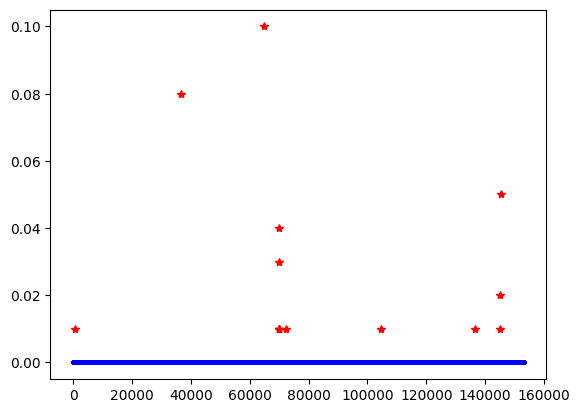

Outliers in column  ice_accretion_3hr  are:  {np.float64(0.08), np.float64(0.1), np.float64(0.03), np.float64(0.05), np.float64(0.01), np.float64(0.04), np.float64(0.02)}
ice_accretion_6hr


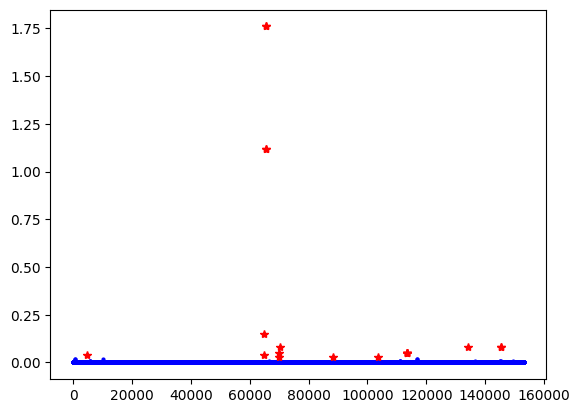

Outliers in column  ice_accretion_6hr  are:  {np.float64(0.03), np.float64(1.76), np.float64(1.12), np.float64(0.15), np.float64(0.05), np.float64(0.08), np.float64(0.04)}
snowdepth


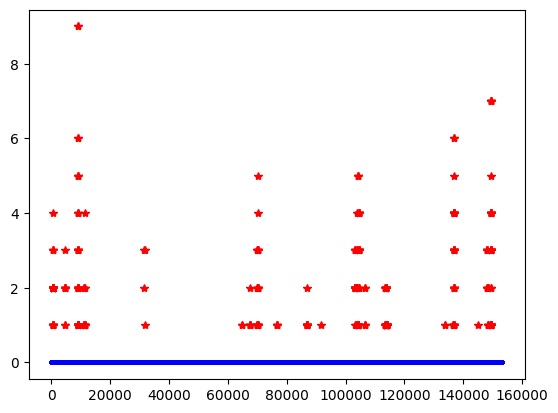

Outliers in column  snowdepth  are:  {np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(9.0)}


In [ ]:
for col in df_outliers_columns:
    print(col)
    outliers = get_outliers_from_column(df, col)
    print("Outliers in column ", col, " are: ", outliers)

### Saving file into a new csv

In [ ]:
df.to_csv('Dec2023Flights_PreparedData.csv', sep=',', encoding='utf-8')